[1.         0.70710678]
ch1,c0, c1, c2_, R45: 908.4697246867393 79.49067827161765 9.58801735970038 13.172950057644956
ch2,c0, c1, c2_, R45: 479.0869987155557 31.750306543263612 4.150141594715732 10.648348662429473
ch3,c0, c1, c2_, R45: 338.7516591882168 15.373085040761612 2.530165245660034 6.985553912632514
ch4,c0, c1, c2_, R45: 251.7065358278275 9.451503473760791 2.967618010036944 5.758176269860431
ch5,c0, c1, c2_, R45: 192.47340754215804 4.881728161795848 4.446308211656167 3.8459998873437415
ch6,c0, c1, c2_, R45: 141.07444984557853 1.2180522167925727 0.5623274757119168 1.2825684790525644
ch1, dry adiabat, Tb, R45: 483.47767607852984 10.021285327178385
ch1, dry adiabat, Tb, R45: 484.14627404231385 9.985140942075994
ch1, dry adiabat, Tb, R45: 484.2134590926971 9.980822769278713
ch1, dry adiabat, Tb, R45: 483.42767124476677 9.985753483390774
ch1, dry adiabat, Tb, R45: 483.5088020806933 9.98054086859137
ch2, dry adiabat, Tb, R45: 332.25922561353894 6.992961800024837
ch2, dry adiabat, Tb,

/tmp/ipykernel_3917022/835451534.py:221: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


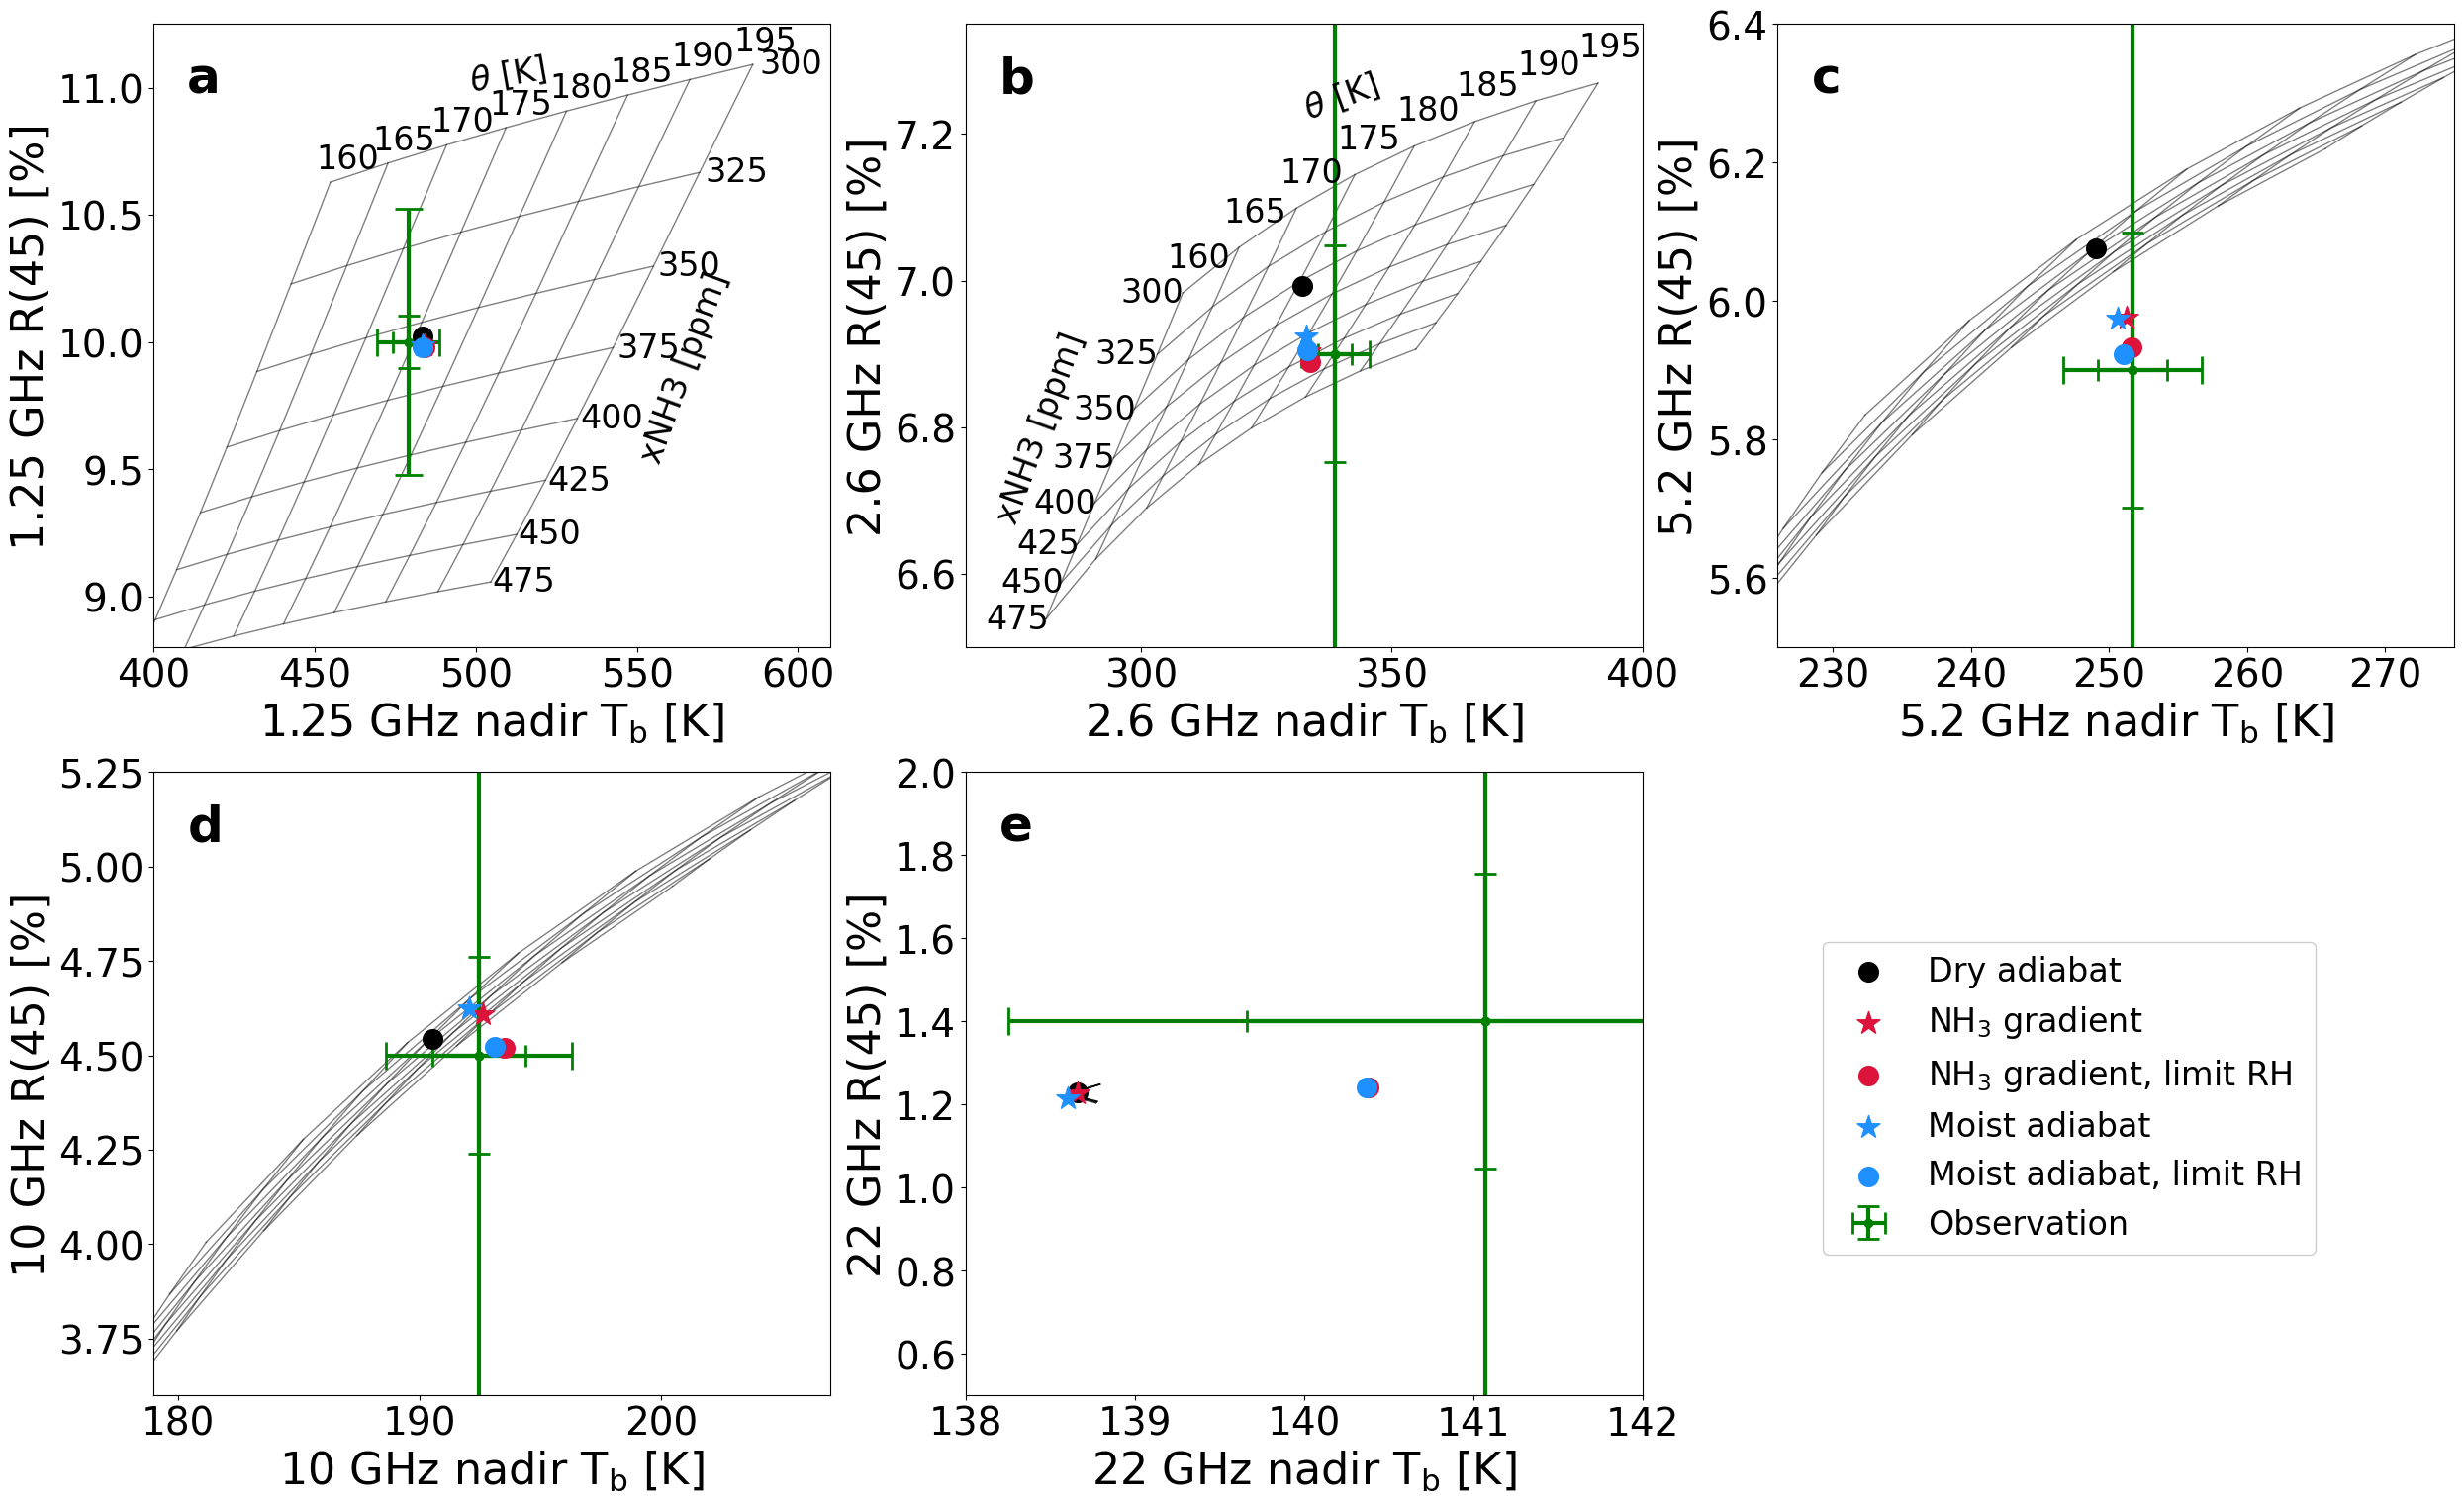

In [7]:
#! /usr/bin/env python3
import numpy as np
import emcee
import sys, os
import matplotlib.pyplot as plt
import h5py
from scipy.stats import norm
from scipy.stats import multivariate_normal
import seaborn as sns
from scipy.stats import gaussian_kde
import pandas as pd


obs = np.zeros((12,))

mu = np.cos(np.array([0.0,  45.0]) / 180.0 * np.pi)
print(mu)


# read MWR coefficients
mwr_coeff = "../mwr_polar_coefficients.csv"
df = pd.read_csv(mwr_coeff, header=None, names=["channel", "c0", "c1", "c2"])
c0 = df["c0"].values
c1 = df["c1"].values
c2 = df["c2"].values

LD0=[1.0, 10.0, 6.9, 5.9, 4.5, 1.4]  # Fabiabo crrection on LD

# generate observations
for ch in range(6):
        # Xr=1.0 ## \mu >0.6
    c0_=c0[ch]
    c1_=c1[ch]
    c2_=c2[ch]


    mu45=np.cos(np.radians(45.0))
    tb45=c0_-c1_*5.0*(1-mu45)+c2_/0.04*0.5*(mu45 - 0.8)*(1 - mu45)
    R45=(c0_-tb45)/c0_*100.0
    # print(f"ch{ch+1},c0, c1, c2_, R45:", c0_, c1_, c2_, R45)
    if ch>0:
        r_=LD0[ch]/R45
        c1_=c1_*r_
        c2_=c2_*r_

    print(f"ch{ch+1},c0, c1, c2_, R45:", c0_, c1_, c2_, R45)

    obs[(ch)*2:(ch+1)*2] =(c0_-c1_*5.0*(1-mu)+c2_/0.04*0.5*(mu - 0.8)*(1 - mu))

    tb45=c0_-c1_*5.0*(1-mu45)+c2_/0.04*0.5*(mu45 - 0.8)*(1 - mu45)

with h5py.File("/home/jihenghu/JHCanoe/build_euler_apative_bg/bin/model_LUT_TB_LD.h5","r") as f:
    TBs=f["TBs"][:]
    LDs=f["LDs"][:]

xNH3s= [300,325,350,375,400,425,450,475]
Thetas  = [160,165,170,175,180,185,190,195]

# Plot the cloud optical depth as contour lines
ich=1

fig, axes = plt.subplots(2,3, figsize=(30,18), dpi=100)  # 2 rows, 3 columns, with a custom figure size

fontsize=24
axs=axes.flatten()





for iax, ax in enumerate(axs[:5]):
    ich=iax+1
    # if ich>2:
        # continue
    for ix, xnh3 in enumerate(xNH3s):
        if ix==0:
            ax.plot(TBs[ix,:,ich], LDs[ix,:,ich],color="k",alpha=0.5, linewidth=1)
        else:
            ax.plot(TBs[ix,:,ich], LDs[ix,:,ich],color="k",alpha=0.5, linewidth=1)
        
        if ich==0:
            ax.text(TBs[ix, 0,ich], LDs[ix, 0,ich]*1.03, f"{xnh3}", rotation=90, fontsize=fontsize, va="center",ha="center")
        elif ich==1:
            ax.text(TBs[ix, -1,ich]*1.02, LDs[ix, -1,ich], f"{xnh3}", fontsize=fontsize, va="center",ha="center")
        elif ich==2:
            ax.text(TBs[ix, 0,ich]*0.98, LDs[ix, 0,ich], f"{xnh3}",  rotation=0, fontsize=fontsize, va="center",ha="center")
        # elif ich==3:
            # ax.text(TBs[ix, 0,ich]*0.985, LDs[ix, 0,ich], f"{xnh3}", color="blue", rotation=0, fontsize=fontsize, va="center",ha="center")
        # if ich<3:
        #     # ax.text(TBs[ix, 0,ich]*0.99, LDs[ix, 0,ich], f"{xnh3}", color="blue", rotation=0, fontsize=fontsize, va="center",ha="center")


    for it, theta in enumerate(Thetas):
        if it==0:
            ax.plot(TBs[:,it,ich], LDs[:,it,ich],color="k",alpha=0.5, linewidth=1)
        else:
            ax.plot(TBs[:,it,ich], LDs[:,it,ich],color="k",alpha=0.5, linewidth=1)

        if ich==0:
            ax.text(TBs[0,it,ich]*1.005, LDs[0,it,ich]*0.995, f"{theta:02d}", fontsize=fontsize)
        elif ich==1:
            ax.text(TBs[0,it,ich]*0.99, LDs[0,it,ich]*1.005, f"{theta:02d}", fontsize=fontsize)
        elif ich==2:
            ax.text(TBs[0,it,ich]*0.99, LDs[0,it,ich]*1.005, f"{theta:02d}", fontsize=fontsize)
        # elif ich==3:
            # ax.text(TBs[0,it,ich]*0.985, LDs[0,it,ich]*1.003, f"{theta:02d}", rotation=20, fontsize=fontsize)
        # elif ich==4:
            # ax.text(TBs[0,it,ich]*0.985, LDs[0,it,ich], f"{theta:02d}", color="red", rotation=20, fontsize=fontsize)

# axs[1].text(780,15.8, "xNH3 [ppm]", color="k",fontsize=fontsize,rotation=-10,va="center",ha="center")
# axs[1].text(950,13.2,r"$\theta$ [K]", color="k",fontsize=fontsize,rotation=-45,va="center",ha="center")

axs[0].text(565,9.9, "xNH3 [ppm]", color="k",fontsize=fontsize,rotation=70,va="center",ha="center")
axs[0].text(510,11.05,r"$\theta$ [K]", color="k",fontsize=fontsize,rotation=10,va="center",ha="center")

axs[1].text(280,6.8, "xNH3 [ppm]", color="k",fontsize=fontsize,rotation=70,va="center",ha="center")
axs[1].text(340,7.25,r"$\theta$ [K]", color="k",fontsize=fontsize,rotation=20,va="center",ha="center")


for iax, ax in enumerate(axs[:5]):
    ich=iax+1

    LD= (-obs[ich*2+1]+obs[ich*2])/obs[ich*2]*100.
    # if ich==4:
    #     LD=4.5
    ax.errorbar(obs[ich*2],LD, xerr=0.01*obs[ich*2], yerr=0.5/obs[ich*2]*100., fmt='o', linewidth=3,capsize=8, capthick=2, label="Observation", color='green')
    ax.errorbar(obs[ich*2],LD, xerr=0.02*obs[ich*2], yerr=2.5/obs[ich*2]*100., fmt='o', linewidth=3,capsize=10,capthick=2, color='green')

    # Add labels and title
    GHz=[0.6,1.25, 2.6, 5.2, 10, 22]
    ax.set_xlabel(fr'{GHz[ich]} GHz nadir T$_\text{{b}}$ [K]', fontsize=32)
    ax.set_ylabel(fr'{GHz[ich]} GHz R(45) [%]', fontsize=32)
    # ax.set_title(f'Channel {ich+1}')

    ax.tick_params(axis='x', labelsize=28)  # Change 14 to any desired font size
    ax.tick_params(axis='y', labelsize=28)  # Change 14 to any desired font size

    ax.text(0.05, 0.95, chr(97+iax), transform=ax.transAxes, fontsize=36, fontweight='bold', va='top', ha='left')




# axs[0].set_xlim(680, 1050)
# axs[0].set_ylim(9, 16.8)

axs[1-1].set_xlim(400, 610)
axs[1-1].set_ylim(8.8, 11.25)

axs[2-1].set_xlim(265, 400)
axs[2-1].set_ylim(6.5, 7.35)

# axs[2].set_xlim(198, 290)
axs[3-1].set_xlim(226, 275)
axs[3-1].set_ylim(5.5, 6.4)

# axs[3].set_xlim(165, 215)
axs[4-1].set_xlim(179, 207)

axs[4-1].set_ylim(3.6, 5.25)

axs[5-1].set_ylim(0.5, 2.0)
axs[5-1].set_xlim(138,142)
# axs[0].set_yticks([9,10,11,12])
# axs[1].set_yticks([6.2,6.6,7.0,7.4,7.8])
# axs[3].set_yticks([5,5.5,6,6.5])



for ix in range(0,5):
    ax = axs[ix]
    ich=ix+1

    # dry adiabatic + uniform qNH3
    h5file=h5py.File('TB_R45_dry_uniform.h5', 'r') ## dry+gradient
    y=    h5file['R45'][ich]
    x=    h5file['BT'][ich]
    h5file.close()
    print(f"ch{ich}, dry adiabat, Tb, R45:", x, y)
    ax.scatter(x,y,marker="o",color="k", s=200, label=r"Dry adiabat", zorder=10)

    # dry adiabatic + uniform qNH3
    h5file=h5py.File('TB_R45_dry_depletedNH3.h5', 'r') ## dry+gradient
    y=    h5file['R45'][ich]
    x=    h5file['BT'][ich]
    h5file.close()
    print(f"ch{ich}, dry adiabat, Tb, R45:", x, y)
    ax.scatter(x,y,marker="*",color="crimson", s=300, label=r"NH$_3$ gradient", zorder=10)


    # dry adiabatic + uniform qNH3
    h5file=h5py.File('TB_R45_dry_depletedNH3_rhmax.h5', 'r') ## dry+gradient
    y=    h5file['R45'][ich]
    x=    h5file['BT'][ich]
    h5file.close()
    print(f"ch{ich}, dry adiabat, Tb, R45:", x, y)
    ax.scatter(x,y,marker="o",color="crimson", s=200, label=r"NH$_3$ gradient, limit RH", zorder=10)



    # dry adiabatic + uniform qNH3
    h5file=h5py.File('../moist_adiab/TB_R45_moist.h5', 'r') ## dry+gradient
    y=    h5file['R45'][ich]
    x=    h5file['BT'][ich]
    h5file.close()
    print(f"ch{ich}, dry adiabat, Tb, R45:", x, y)
    ax.scatter(x,y,marker="*",color="dodgerblue", s=300, label=r"Moist adiabat", zorder=10)


    # dry adiabatic + uniform qNH3
    h5file=h5py.File('../moist_adiab/TB_R45_moist_rhmax.h5', 'r') ## dry+gradient
    y=    h5file['R45'][ich]
    x=    h5file['BT'][ich]
    h5file.close()
    print(f"ch{ich}, dry adiabat, Tb, R45:", x, y)
    ax.scatter(x,y,marker="o",color="dodgerblue", s=200, label=r"Moist adiabat, limit RH", zorder=10)



axs[0].legend(fontsize=24, ncol=1, loc='lower right', framealpha=1, bbox_to_anchor=(3.22, -1))
axs[5].axis('off') 
plt.tight_layout()

plt.savefig("check_fit_dry_case.pdf", transparent=True, bbox_inches='tight')
plt.show()
